## Confirm GPUs

In [1]:
import torch
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

2
Tesla T4


In [2]:
!pip install -q transformers peft accelerate bitsandbytes datasets anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 47.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 42.6 MB/s eta 0:00:00


## Set Anthropic API key

In [3]:
import os
os.environ["ANTHROPIC_API_KEY"] = " "

## Load the Alpaca dataset


In [4]:
from datasets import load_dataset

dataset = load_dataset("tatsu-lab/alpaca", split="train")

print(f"Total examples in Alpaca: {len(dataset)}")
print("\n--- Example 1 ---")
print(dataset[0])
print("\n--- Example 2 ---")
print(dataset[1])
print("\n--- Example 3 ---")
print(dataset[2])

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

Total examples in Alpaca: 52002

--- Example 1 ---
{'instruction': 'Give three tips for staying healthy.', 'input': '', 'output': '1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. \n2. Exercise regularly to keep your body active and strong. \n3. Get enough sleep and maintain a consistent sleep schedule.', 'text': 'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nGive three tips for staying healthy.\n\n### Response:\n1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. \n2. Exercise regularly to keep your body active and strong. \n3. Get enough sleep and maintain a consistent sleep schedule.'}

--- Example 2 ---
{'instruction': 'What are the three primary colors?', 'input': '', 'output': 'The three primary colors are red, blue, and yellow.', 'text': 'Below is an instruction that describes a task. Write a response that appropriately completes the request

In [5]:
from datasets import load_dataset
import json, random

dataset = load_dataset("tatsu-lab/alpaca", split="train")
print(f"Total examples in Alpaca: {len(dataset)}")

random.seed(42)
sample_indices = random.sample(range(len(dataset)), 60)
sample = dataset.select(sample_indices)

train_raw = sample.select(range(50))
eval_raw = sample.select(range(50, 60))

print("\n--- Example training item ---")
print(train_raw[0])

Total examples in Alpaca: 52002

--- Example training item ---
{'instruction': 'What are the advantages of using a Scrum Agile methodology?', 'input': '', 'output': 'The advantages of using a Scrum Agile methodology include improved communication, increased accountability, faster project completion, better quality projects, greater customer satisfaction, and better team morale. Additionally, using Scrum Agile allows teams to more easily pivot and respond to changing requirements, which is often necessary in software development.', 'text': 'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nWhat are the advantages of using a Scrum Agile methodology?\n\n### Response:\nThe advantages of using a Scrum Agile methodology include improved communication, increased accountability, faster project completion, better quality projects, greater customer satisfaction, and better team morale. Additionally, using Scrum Agile al

In [6]:
def to_jsonl(ds, path):
    with open(path, "w") as f:
        for row in ds:
            question = row["instruction"] + ((" " + row["input"]) if row["input"] else "")
            f.write(json.dumps({"question": question, "answer": row["output"]}) + "\n")

to_jsonl(train_raw, "raw_train.jsonl")
to_jsonl(eval_raw, "eval_holdout.jsonl")

print("Wrote raw_train.jsonl (50 examples) and eval_holdout.jsonl (10 examples)")

Wrote raw_train.jsonl (50 examples) and eval_holdout.jsonl (10 examples)


In [7]:
import pandas as pd

train_df = pd.read_json("raw_train.jsonl", lines=True)
eval_df = pd.read_json("eval_holdout.jsonl", lines=True)

print(f"Train examples: {len(train_df)}")
print(f"Eval examples: {len(eval_df)}")

print("\n--- First 5 training examples ---")
display(train_df.head())

print("\n--- Eval holdout examples ---")
display(eval_df)

Train examples: 50
Eval examples: 10

--- First 5 training examples ---


,question,answer
0,What are the advantages of using a Scrum Agile...,The advantages of using a Scrum Agile methodol...
1,Design an advertisement for a home security pr...,Stay secure and monitored with [Product Name]!...
2,Cite a relevant quote that reflects the messag...,"""Our greatest weakness lies in giving up. The ..."
3,Generate two similar sounding but semantically...,Bright and Dim.
4,Explain the engineering design process.,The engineering design process is an iterative...



--- Eval holdout examples ---


,question,answer
0,Find the main concept expressed in the followi...,Going against social norms.
1,Outline the major points of the US Constitution.,The main points of the US Constitution include...
2,Annotate the text by categorizing it into the ...,"I can’t wait to [taste] the [warm], [fruity] m..."
3,Convert the following Roman numeral to its equ...,27
4,Compare a the customer service experience of t...,Comparing the customer service experience of t...
5,Generate a resumé for a data scientist.,John Smith\nData Scientist\n\nSummary\n\nHighl...
6,Design a unique logo for a pet store using the...,A round logo featuring a stylized image of a d...
7,Describe a potential risk of using artificial ...,One potential risk of using artificial intelli...
8,Identify the subject and the action of the sen...,Subject: dog Action: barked
9,"Given the input, explain how the design of the...",The design of the website for the Cold Creek C...


# ****1. Data curation layer****

In [8]:
import anthropic
import json
import time

client = anthropic.Anthropic()

CURATION_PROMPT = '''You are reviewing a candidate training example for fine-tuning a language model.

Question: {question}
Answer: {answer}

First, check: does the answer actually do what the question asks? (e.g. if asked for similar-SOUNDING words, opposite-MEANING words would be wrong even if grammatically fine). Note this explicitly in your reason if there's a mismatch.

Score this example from 0-10 on each dimension, using these anchors:

CLARITY:
- 0-3: question or answer is ambiguous, contradictory, or confusing
- 4-6: understandable but imprecise or could be misread
- 7-10: fully clear and unambiguous

CORRECTNESS:
- 0-3: factually or logically wrong, OR fails to actually do what the task asked
- 4-6: mostly correct but with a notable gap, oversimplification, or minor error
- 7-10: fully accurate, sound, and correctly fulfills the task

VALUE:
- 0-3: trivial, boilerplate, or teaches nothing useful
- 4-6: reasonable but generic, common knowledge with little depth
- 7-10: substantive, specific, and genuinely useful for training

You MUST always include a "reason" field with a specific, non-empty explanation — never omit it.

Respond ONLY with a JSON object like this, no other text:
{{"clarity": <0-10>, "correctness": <0-10>, "value": <0-10>, "reason": "<specific sentence explaining the scores, including any task-mismatch found>"}}'''


def curate_example(example, retries=1):
    prompt = CURATION_PROMPT.format(question=example["question"], answer=example["answer"])

    for attempt in range(retries + 1):
        response = client.messages.create(
            model="claude-haiku-4-5-20251001",
            max_tokens=400,
            temperature=0 if attempt == 0 else 0.3,
            messages=[{"role": "user", "content": prompt}]
        )
        text = response.content[0].text.strip()

        if text.startswith("```"):
            text = text.split("```")[1]
            if text.startswith("json"):
                text = text[4:]
            text = text.strip()

        try:
            result = json.loads(text)
            if result.get("reason") and all(k in result for k in ["clarity", "correctness", "value"]):
                result["avg_score"] = (result["clarity"] + result["correctness"] + result["value"]) / 3
                return result
            # missing reason or a score field -> fall through and retry
        except json.JSONDecodeError:
            pass  # malformed JSON -> retry

    # all retries exhausted — genuine, clearly-labeled failure (not a silent default)
    return {"clarity": 5, "correctness": 5, "value": 5, "avg_score": 5.0,
            "reason": "FAILED_TO_GET_VALID_RESPONSE_AFTER_RETRY"}

In [9]:
raw_examples = [json.loads(l) for l in open("raw_train.jsonl")]

scored_examples = []
for ex in raw_examples:
    scores = curate_example(ex)
    ex["_curation"] = scores
    scored_examples.append(ex)
    time.sleep(0.3)

print(f"Scored {len(scored_examples)} examples")
failed = [e for e in scored_examples if e["_curation"]["reason"] == "FAILED_TO_GET_VALID_RESPONSE_AFTER_RETRY"]
print(f"Genuine failures after retry: {len(failed)}")
print(f"Score distribution (avg_score): min={min(e['_curation']['avg_score'] for e in scored_examples):.1f}, "
      f"max={max(e['_curation']['avg_score'] for e in scored_examples):.1f}")

Scored 50 examples
Genuine failures after retry: 2
Score distribution (avg_score): min=4.0, max=8.7


In [10]:
scores = sorted(e["_curation"]["avg_score"] for e in scored_examples)
print("All scores:", scores)
print(f"Min: {min(scores)}, Max: {max(scores)}, Median: {scores[len(scores)//2]}")

# Test thresholds actually spanning your real range
import numpy as np
test_thresholds = np.linspace(min(scores), max(scores), 6)
for t in test_thresholds:
    kept = [e for e in scored_examples if e["_curation"]["avg_score"] >= t]
    print(f"Threshold {t:.2f}: keep {len(kept)}, reject {len(scored_examples) - len(kept)}")

All scores: [4.0, 4.0, 4.666666666666667, 5.0, 5.0, 5.0, 5.0, 5.333333333333333, 6.0, 6.0, 6.666666666666667, 6.666666666666667, 6.666666666666667, 6.666666666666667, 7.0, 7.0, 7.0, 7.333333333333333, 7.333333333333333, 7.333333333333333, 7.333333333333333, 7.333333333333333, 7.666666666666667, 7.666666666666667, 7.666666666666667, 7.666666666666667, 7.666666666666667, 7.666666666666667, 7.666666666666667, 7.666666666666667, 7.666666666666667, 7.666666666666667, 7.666666666666667, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.333333333333334, 8.333333333333334, 8.333333333333334, 8.333333333333334, 8.333333333333334, 8.666666666666666, 8.666666666666666]
Min: 4.0, Max: 8.666666666666666, Median: 7.666666666666667
Threshold 4.00: keep 50, reject 0
Threshold 4.93: keep 47, reject 3
Threshold 5.87: keep 42, reject 8
Threshold 6.80: keep 36, reject 14
Threshold 7.73: keep 17, reject 33
Threshold 8.67: keep 2, reject 48


In [11]:
THRESHOLD = 6.7

curated = [e for e in scored_examples if e["_curation"]["avg_score"] >= THRESHOLD]
rejected = [e for e in scored_examples if e["_curation"]["avg_score"] < THRESHOLD]

print(f"Threshold: {THRESHOLD}")
print(f"Kept: {len(curated)} / {len(scored_examples)}")
print(f"Rejected: {len(rejected)}")

Threshold: 6.7
Kept: 36 / 50
Rejected: 14


In [12]:
for ex in curated:
    print("Question:", ex["question"])
    print("Answer:", ex["answer"])
    print("Clarity:", ex["_curation"]["clarity"])
    print("Correctness:", ex["_curation"]["correctness"])
    print("Value:", ex["_curation"]["value"])
    print("Reason:", ex["_curation"]["reason"])
    print("\n" + "="*80 + "\n")

Question: What are the advantages of using a Scrum Agile methodology?
Answer: The advantages of using a Scrum Agile methodology include improved communication, increased accountability, faster project completion, better quality projects, greater customer satisfaction, and better team morale. Additionally, using Scrum Agile allows teams to more easily pivot and respond to changing requirements, which is often necessary in software development.
Clarity: 8
Correctness: 8
Value: 6
Reason: The answer directly addresses the question asked and provides a clear list of Scrum Agile advantages. The response is accurate and well-organized, covering both interpersonal benefits (communication, morale, accountability) and project outcomes (speed, quality, customer satisfaction). The mention of flexibility/pivoting is particularly relevant to modern software development. However, the value is moderate because the answer is somewhat generic and surface-level—it lists advantages without explaining the 

In [13]:
for ex in rejected:
    print("Question:", ex["question"])
    print("Answer:", ex["answer"])
    print("Clarity:", ex["_curation"]["clarity"])
    print("Correctness:", ex["_curation"]["correctness"])
    print("Value:", ex["_curation"]["value"])
    print("Reason:", ex["_curation"]["reason"])
    print("\n" + "="*80 + "\n")

Question: Design an advertisement for a home security product.
Answer: Stay secure and monitored with [Product Name]! Our cutting-edge home security system keeps you connected no matter where you are in the world. With built-in sensors and 24/7 monitoring, you can rest easy knowing that your home is safe and sound. Get [Product Name] today and take complete control over your home security.
Clarity: 5
Correctness: 5
Value: 5
Reason: FAILED_TO_GET_VALID_RESPONSE_AFTER_RETRY


Question: Generate two similar sounding but semantically different words to contrast this word. Light
Answer: Bright and Dim.
Clarity: 8
Correctness: 3
Value: 4
Reason: The question asks for 'similar sounding but semantically different words,' which requires phonetic similarity paired with semantic contrast. However, 'Bright' and 'Dim' are semantically opposite (which is good) but do NOT sound similar to 'Light' or to each other—this is a fundamental task mismatch. The answer appears to confuse the task with finding

In [14]:
with open("curated_train.jsonl", "w") as f:
    for ex in curated:
        f.write(json.dumps({"question": ex["question"], "answer": ex["answer"]}) + "\n")

with open("curation_report.md", "w") as f:
    f.write(f"# Curation Report\n\n")
    f.write(f"- Raw examples: {len(raw_examples)}\n")
    f.write(f"- Kept after Haiku curation: {len(curated)}\n")
    f.write(f"- Rejected: {len(rejected)}\n\n")
    f.write("## Sample rejections\n\n")
    for ex in rejected[:5]:
        f.write(f"**Q:** {ex['question']}\n\n**A:** {ex['answer']}\n\n**Reason:** {ex['_curation'].get('reason','')}\n\n---\n\n")

print(open("curation_report.md").read())

# Curation Report

- Raw examples: 50
- Kept after Haiku curation: 36
- Rejected: 14

## Sample rejections

**Q:** Design an advertisement for a home security product.

**A:** Stay secure and monitored with [Product Name]! Our cutting-edge home security system keeps you connected no matter where you are in the world. With built-in sensors and 24/7 monitoring, you can rest easy knowing that your home is safe and sound. Get [Product Name] today and take complete control over your home security.

**Reason:** FAILED_TO_GET_VALID_RESPONSE_AFTER_RETRY

---

**Q:** Generate two similar sounding but semantically different words to contrast this word. Light

**A:** Bright and Dim.

**Reason:** The question asks for 'similar sounding but semantically different words,' which requires phonetic similarity paired with semantic contrast. However, 'Bright' and 'Dim' are semantically opposite (which is good) but do NOT sound similar to 'Light' or to each other—this is a fundamental task mismatch. The a

# 2.Training &  Monitoring 

****model_1****

In [15]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

print("Base model loaded:", MODEL_NAME)
print("Num parameters:", sum(p.numel() for p in base_model.parameters()) / 1e6, "M")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Base model loaded: Qwen/Qwen2.5-1.5B-Instruct
Num parameters: 1543.714304 M


In [27]:
def generate(model, tok, question, max_new_tokens=500):
    messages = [{"role": "user", "content": question}]
    inputs = tok.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, pad_token_id=tok.eos_token_id)
    inputs_len = inputs["input_ids"].shape[1]
    return tok.decode(out[0][inputs_len:], skip_special_tokens=True)

eval_examples = [json.loads(l) for l in open("eval_holdout.jsonl")]

base_outputs = []
import time as _t
for ex in eval_examples:
    start = _t.time()
    output = generate(base_model, tokenizer, ex["question"])
    elapsed = _t.time() - start
    base_outputs.append({
        "question": ex["question"],
        "reference": ex["answer"],
        "base_output": output,
        "base_latency_s": elapsed
    })

with open("base_outputs.jsonl", "w") as f:
    for row in base_outputs:
        f.write(json.dumps(row) + "\n")

print("Sample base output:")
print(base_outputs[0])

Sample base output:
{'question': 'Find the main concept expressed in the following sentence. He acted in a way that went against all social norms.', 'reference': 'Going against social norms.', 'base_output': 'The main concept expressed in the sentence is "deviation from societal expectations."', 'base_latency_s': 1.2527616024017334}


****model_1_tuning****

In [17]:
!pip install -q -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 37.5 MB/s eta 0:00:0000:0100:01


In [19]:
from peft import LoraConfig, get_peft_model
from datasets import Dataset

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

curated_data = [json.loads(l) for l in open("curated_train.jsonl")]

def format_example(ex):
    messages = [
        {"role": "user", "content": ex["question"]},
        {"role": "assistant", "content": ex["answer"]}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False)
    return {"text": text}

formatted = [format_example(ex) for ex in curated_data]
train_dataset = Dataset.from_list(formatted)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=512, padding="max_length")

tokenized_dataset = train_dataset.map(tokenize_fn, batched=True)
print(tokenized_dataset)

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


trainable params: 1,089,536 || all params: 1,544,803,840 || trainable%: 0.0705


Map:   0%|          | 0/36 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'input_ids', 'attention_mask'],
    num_rows: 36
})


In [21]:
print(tokenizer.decode(tokenized_dataset[0]["input_ids"]))

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
What are the advantages of using a Scrum Agile methodology?<|im_end|>
<|im_start|>assistant
The advantages of using a Scrum Agile methodology include improved communication, increased accountability, faster project completion, better quality projects, greater customer satisfaction, and better team morale. Additionally, using Scrum Agile allows teams to more easily pivot and respond to changing requirements, which is often necessary in software development.<|im_end|>
<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext

# ****Training****

In [22]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
import time as _t2

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir="./smartune-checkpoints",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=5,
    save_strategy="epoch",
    bf16=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    data_collator=data_collator
)

start = _t2.time()
train_result = trainer.train()
elapsed = _t2.time() - start

throughput = (len(tokenized_dataset) * training_args.num_train_epochs) / elapsed
peak_mem_gb = torch.cuda.max_memory_allocated() / 1e9

print(f"Training time: {elapsed:.1f}s")
print(f"Approx throughput: {throughput:.2f} examples/sec")
print(f"Peak GPU memory: {peak_mem_gb:.2f} GB")
print(f"Final training loss: {train_result.training_loss:.4f}")

with open("training_metrics.json", "w") as f:
    json.dump({
        "training_time_s": elapsed,
        "throughput_examples_per_sec": throughput,
        "peak_gpu_memory_gb": peak_mem_gb,
        "final_loss": train_result.training_loss
    }, f, indent=2)

Step,Training Loss
5,2.581109
10,2.088890
15,1.867443
20,1.604909
25,1.684142


Training time: 170.1s
Approx throughput: 0.63 examples/sec
Peak GPU memory: 4.73 GB
Final training loss: 1.9350


Plot and diagnose idea

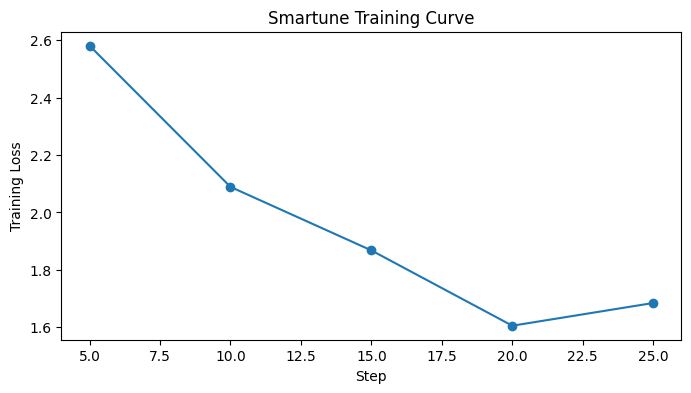

In [24]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
steps = [entry["step"] for entry in log_history if "loss" in entry]
losses = [entry["loss"] for entry in log_history if "loss" in entry]

plt.figure(figsize=(8, 4))
plt.plot(steps, losses, marker="o")
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("Smartune Training Curve")
plt.savefig("training_curve.png")
plt.show()

# 3. EVALUATION

In [34]:
JUDGE_PROMPT = '''You are judging two AI responses to the same question, against a reference answer.

Question: {question}
Reference answer: {reference}

Response A: {response_a}
Response B: {response_b}

Score each response 0-10 on quality, coherence, and task-fit (how well it actually answers the question).
Then say which response is better overall: "A", "B", or "tie".

Respond ONLY with JSON, no other text:
{{"score_a": {{"quality": <0-10>, "coherence": <0-10>, "task_fit": <0-10>}}, "score_b": {{"quality": <0-10>, "coherence": <0-10>, "task_fit": <0-10>}}, "winner": "<A, B, or tie>", "reason": "<one short sentence>"}}'''

def judge(question, reference, response_a, response_b):
    prompt = JUDGE_PROMPT.format(question=question, reference=reference, response_a=response_a, response_b=response_b)
    response = client.messages.create(
        model="claude-sonnet-4-5",
        max_tokens=300,
        temperature=0,
        messages=[{"role": "user", "content": prompt}]
    )
    text = response.content[0].text.strip()

    if text.startswith("```"):
        text = text.split("```")[1]
        if text.startswith("json"):
            text = text[4:]
        text = text.strip()

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        return {"winner": "parse_failed", "reason": "could not parse judge output"}

base_data = [json.loads(l) for l in open("base_outputs.jsonl")]
ft_data = [json.loads(l) for l in open("finetuned_outputs.jsonl")]

judged_results = []
for b, f_ in zip(base_data, ft_data):
    result = judge(b["question"], b["reference"], b["base_output"], f_["finetuned_output"])
    result["question"] = b["question"]
    judged_results.append(result)
    time.sleep(0.3)

wins_a = sum(1 for r in judged_results if r.get("winner") == "A")
wins_b = sum(1 for r in judged_results if r.get("winner") == "B")
ties = sum(1 for r in judged_results if r.get("winner") == "tie")

print(f"Base model (A) wins: {wins_a}")
print(f"Fine-tuned model (B) wins: {wins_b}")
print(f"Ties: {ties}")

for r in judged_results:
    print(r.get("question"))
    print("Winner:", r.get("winner"), "-", r.get("reason"))
    print("---")

Base model (A) wins: 1
Fine-tuned model (B) wins: 5
Ties: 4
Find the main concept expressed in the following sentence. He acted in a way that went against all social norms.
Winner: tie - Both responses accurately identify the main concept with nearly identical phrasing, differing only by the addition of "or standards" in Response A, which is negligible.
---
Outline the major points of the US Constitution.
Winner: B - Response B better captures the major constitutional principles and structures that align with the reference answer, while Response A focuses too heavily on descriptive details of the branches rather than the Constitution's main points.
---
Annotate the text by categorizing it into the five senses. I can’t wait to taste the warm, fruity muffin I just made.
Winner: tie - Both responses fail to annotate the text as requested and miss that 'warm' relates to touch and 'fruity' could relate to smell/taste, only identifying the overall sense category rather than marking specific 

In [35]:
base_data = [json.loads(l) for l in open("base_outputs.jsonl")]
ft_data = [json.loads(l) for l in open("finetuned_outputs.jsonl")]

for b, f_ in zip(base_data, ft_data):
    print("QUESTION:", b["question"])
    print("REFERENCE:", b["reference"])
    print()
    print("BASE OUTPUT:")
    print(b["base_output"])
    print()
    print("FINE-TUNED OUTPUT:")
    print(f_["finetuned_output"])
    print()
    print("Base ends cleanly:", b["base_output"].rstrip().endswith((".", "!", "?", '"')))
    print("Fine-tuned ends cleanly:", f_["finetuned_output"].rstrip().endswith((".", "!", "?", '"')))
    print("="*100)

QUESTION: Find the main concept expressed in the following sentence. He acted in a way that went against all social norms.
REFERENCE: Going against social norms.

BASE OUTPUT:
The main concept expressed in the sentence is "deviation from societal expectations or standards."

FINE-TUNED OUTPUT:
The main concept expressed in the sentence is "deviation from societal expectations."

Base ends cleanly: True
Fine-tuned ends cleanly: True
QUESTION: Outline the major points of the US Constitution.
REFERENCE: The main points of the US Constitution include: establishing the nation's form of government; setting limits on the powers of the three branches of the federal government; protecting certain fundamental rights for citizens; providing for the election of federal officials; giving Congress the power to tax and regulate commerce; creating a system of laws and courts to enforce the Constitution; and creating a process for amending the Constitution.

BASE OUTPUT:
The United States Constitution 

In [36]:
avg_base_latency = sum(b["base_latency_s"] for b in base_data) / len(base_data)
avg_ft_latency = sum(f_["finetuned_latency_s"] for f_ in ft_data) / len(ft_data)

with open("eval_report.md", "w") as f:
    f.write("# Evaluation Report\n\n")
    f.write("## Training\n\n")
    metrics = json.load(open("training_metrics.json"))
    for k, v in metrics.items():
        f.write(f"- {k}: {v}\n")
    f.write("\n## Latency\n\n")
    f.write(f"- Avg base model latency: {avg_base_latency:.3f}s\n")
    f.write(f"- Avg fine-tuned model latency: {avg_ft_latency:.3f}s\n")
    f.write("\n## Sonnet Judge Results\n\n")
    f.write(f"- Base model wins: {wins_a}\n")
    f.write(f"- Fine-tuned model wins: {wins_b}\n")
    f.write(f"- Ties: {ties}\n\n")
    f.write("## Sample judged comparison\n\n")
    for r in judged_results[:3]:
        f.write(f"**Q:** {r['question']}\n\n**Winner:** {r.get('winner')}  \n**Reason:** {r.get('reason')}\n\n---\n\n")

print(open("eval_report.md").read())

# Evaluation Report

## Training

- training_time_s: 170.13723254203796
- throughput_examples_per_sec: 0.6347816899708597
- peak_gpu_memory_gb: 4.72675072
- final_loss: 1.9349771075778537

## Latency

- Avg base model latency: 8.149s
- Avg fine-tuned model latency: 8.887s

## Sonnet Judge Results

- Base model wins: 1
- Fine-tuned model wins: 5
- Ties: 4

## Sample judged comparison

**Q:** Find the main concept expressed in the following sentence. He acted in a way that went against all social norms.

**Winner:** tie  
**Reason:** Both responses accurately identify the main concept with nearly identical phrasing, differing only by the addition of "or standards" in Response A, which is negligible.

---

**Q:** Outline the major points of the US Constitution.

**Winner:** B  
**Reason:** Response B better captures the major constitutional principles and structures that align with the reference answer, while Response A focuses too heavily on descriptive details of the branches rather tha